Bibliotecas importadas com sucesso.
Dataset carregado: 1470 linhas, 62 colunas
Features utilizadas: 53
Distribuicao da variavel alvo:
Attrition_bin
0    1233
1     237
Name: count, dtype: int64
  Percentagem Yes (1): 16.1%

Treino: 1176 observacoes
Teste:  294 observacoes
  % Yes treino: 16.2%
  % Yes teste:  16.0%

Modelo treinado.
  Profundidade da arvore: 17
  Numero de folhas:       146

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

===== METRICAS — TESTE =====
  F1-Score:  0.3784
  Precision: 0.3281
  Recall:    0.4468
  AUC-ROC:   0.6364

              precision    recall  f1-score   support

  

,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.3784,0.3281,0.4468,0.6364



  Diferenca F1 (treino - teste): 0.6216
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


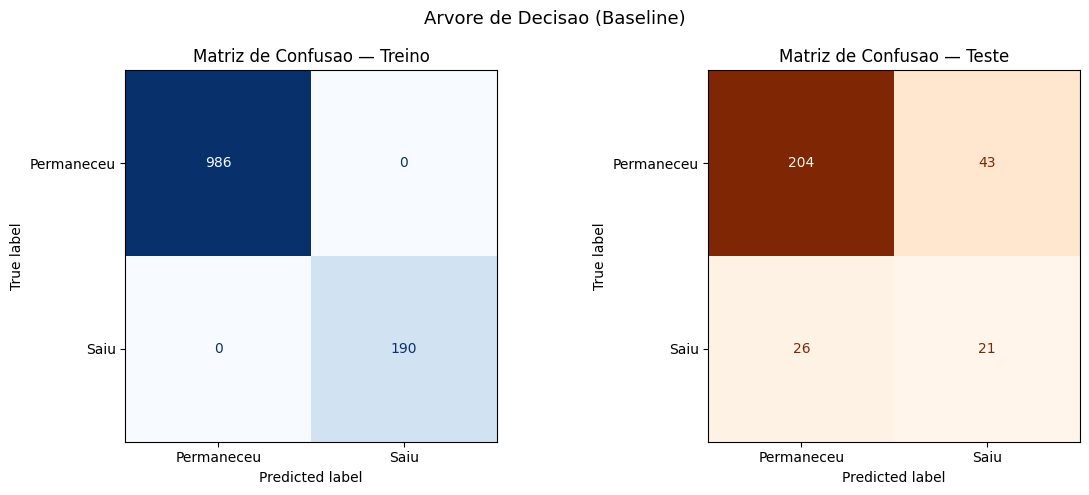

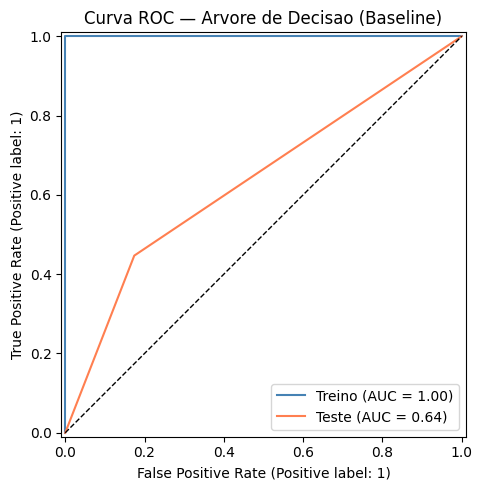

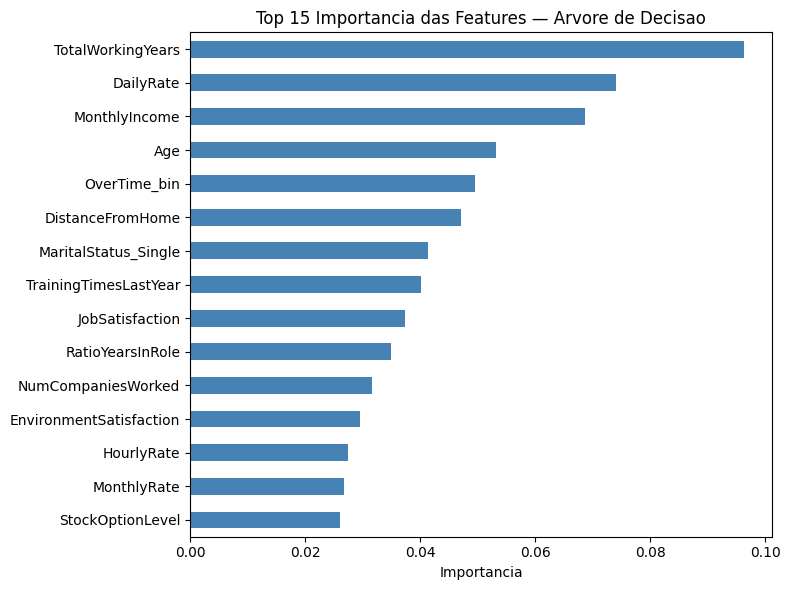

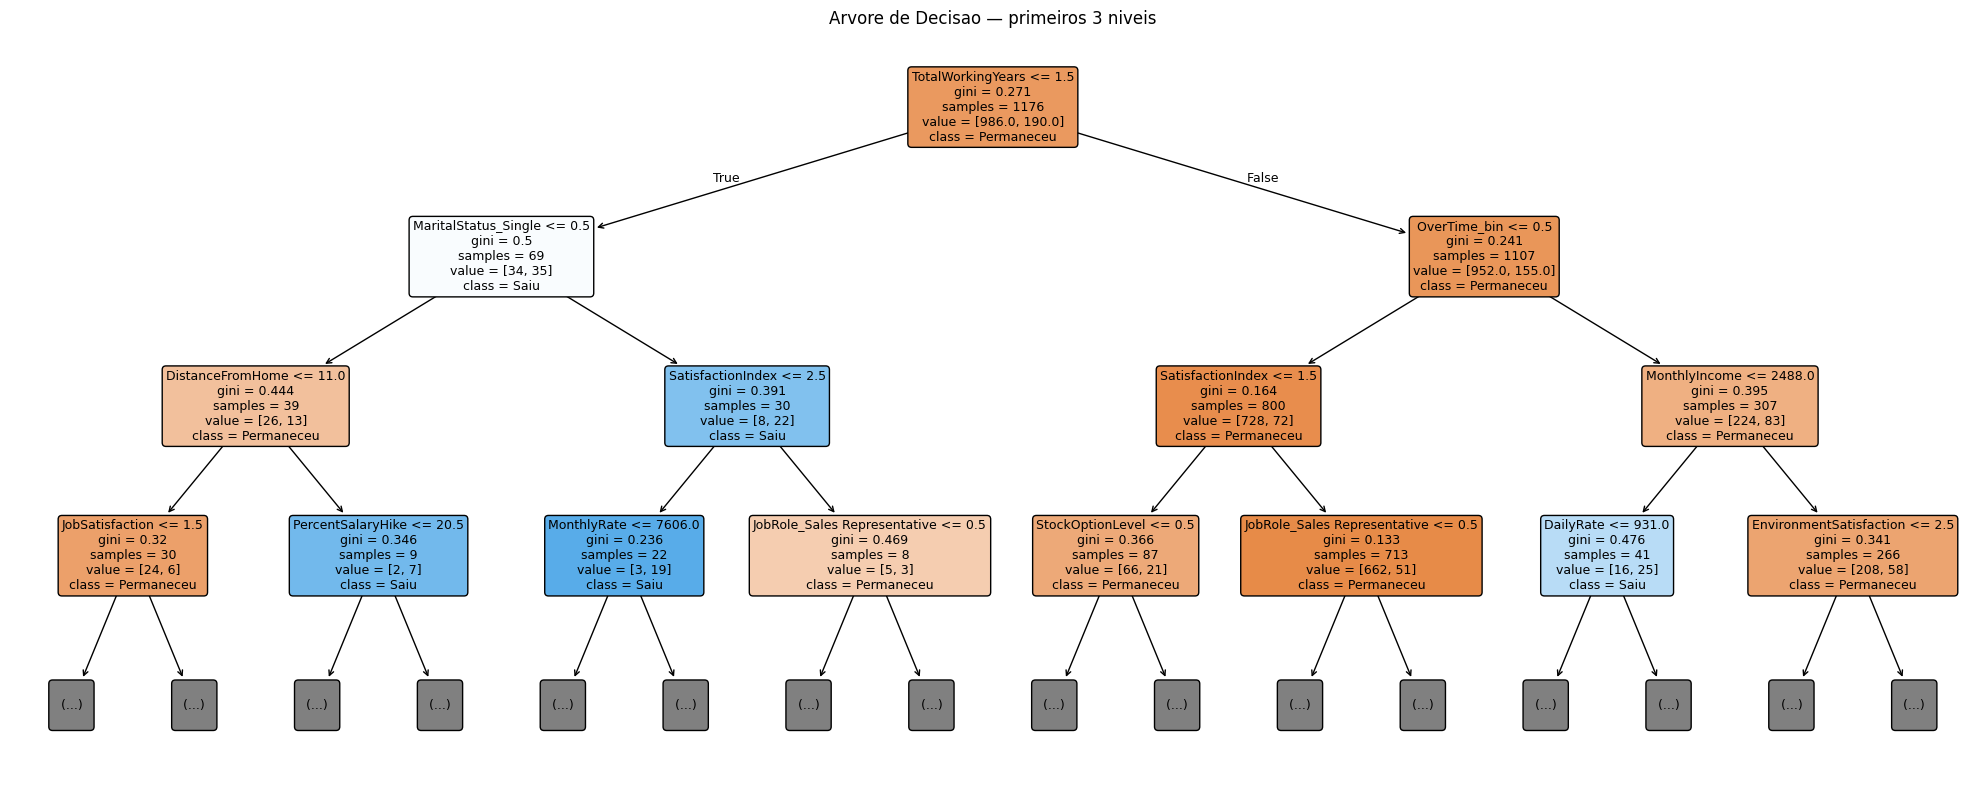


===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 204  OK
  FP — Permaneceu, previsto Saiu:       43  Erro
  FN — Saiu, previsto Permaneceu:       26  Erro (critico)
  TP — Saiu, previsto Saiu:             21  OK

  O modelo falhou em detetar 26 saidas reais (Falsos Negativos).

RESUMO — BASELINE Notebook 1
  Algoritmo:         Arvore de Decisao (parâmetros default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (nao necessaria)
  Balanceamento:     Nenhum (baseline simples)
  Metrica principal: F1-Score
  Profundidade:      17 niveis

  F1 treino: 1.0000
  F1 teste:  0.3784

  Referencial minimo para os modelos candidatos.


In [1]:
# ── 1. IMPORTAÇÕES ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")


# ── 2. CARREGAMENTO DO DATASET ─────────────────────────────────────────────────

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")


# ── 3. PREPARAÇÃO DAS FEATURES ────────────────────────────────────────────────

cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]

cols_remover = [c for c in cols_remover if c in df.columns]
df_model = df.drop(columns=cols_remover)

TARGET = "Attrition_bin"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
X = X.select_dtypes(include=[np.number])

print(f"Features utilizadas: {X.shape[1]}")
print(f"Distribuicao da variavel alvo:")
print(y.value_counts())
print(f"  Percentagem Yes (1): {y.mean()*100:.1f}%")


# ── 4. DIVISÃO TREINO / TESTE ─────────────────────────────────────────────────
# 80% treino, 20% teste
# stratify=y — garante a mesma proporção de Yes/No em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

print("")
print(f"Treino: {X_train.shape[0]} observacoes")
print(f"Teste:  {X_test.shape[0]} observacoes")
print(f"  % Yes treino: {y_train.mean()*100:.1f}%")
print(f"  % Yes teste:  {y_test.mean()*100:.1f}%")


# ── 5. TREINO DO MODELO ───────────────────────────────────────────────────────
# DecisionTreeClassifier() — todos os parâmetros default

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("")
print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf.get_depth()}")
print(f"  Numero de folhas:       {clf.get_n_leaves()}")


# ── 6. MÉTRICAS NO TREINO ─────────────────────────────────────────────────────

y_pred_train  = clf.predict(X_train)
y_proba_train = clf.predict_proba(X_train)[:, 1]

print("")
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print("")
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))


# ── 7. MÉTRICAS NO TESTE ──────────────────────────────────────────────────────

y_pred_test  = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)[:, 1]

print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print("")
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))


# ── 8. TABELA COMPARATIVA TREINO vs TESTE ────────────────────────────────────

resultados = pd.DataFrame({
    "Conjunto":    ["Treino", "Teste"],
    "F1-Score":    [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision":   [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":      [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":     [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)

print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados)

diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print("")
print(f"  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")


# ── 9. VISUALIZAÇÕES ──────────────────────────────────────────────────────────

# 9.1 Matrizes de Confusão — Treino e Teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_train, y_pred_train),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")

fig.suptitle("Arvore de Decisao (Baseline)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 9.2 Curva ROC — Treino e Teste
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore de Decisao (Baseline)")
plt.tight_layout()
plt.savefig("roc_curve_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 9.3 Top 15 Importância das Features
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore de Decisao")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 9.4 Visualização da Árvore (primeiros 3 níveis)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf, max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 10. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE) ─────────────────────────────────

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("")
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print("")
print(f"  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")


# ── 11. RESUMO FINAL ──────────────────────────────────────────────────────────

print("")
print("=" * 55)
print("RESUMO — BASELINE Notebook 1")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao (parâmetros default)")
print(f"  Features:          {X.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (nao necessaria)")
print(f"  Balanceamento:     Nenhum (baseline simples)")
print(f"  Metrica principal: F1-Score")
print(f"  Profundidade:      {clf.get_depth()} niveis")
print("")
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print("")
print("  Referencial minimo para os modelos candidatos.")
print("=" * 55)



Bibliotecas importadas com sucesso.
Dataset carregado: 1470 linhas, 62 colunas
Features utilizadas: 53
Treino: 1176 obs | Teste: 294 obs
Modelo treinado.

===== MÉTRICAS — Treino =====
  Accuracy:   0.9065
  Precision:  0.8175
  Recall:     0.5421
  F1-Score:   0.6519
  AUC-ROC:    0.8819

--- Classification Report (Treino) ---
              precision    recall  f1-score   support

       Ficou       0.92      0.98      0.95       986
        Saiu       0.82      0.54      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.91      0.90      1176



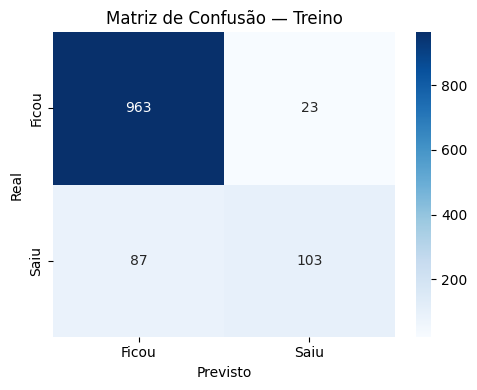


===== MÉTRICAS — Teste =====
  Accuracy:   0.8639
  Precision:  0.6296
  Recall:     0.3617
  F1-Score:   0.4595
  AUC-ROC:    0.8170

--- Classification Report (Teste) ---
              precision    recall  f1-score   support

       Ficou       0.89      0.96      0.92       247
        Saiu       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



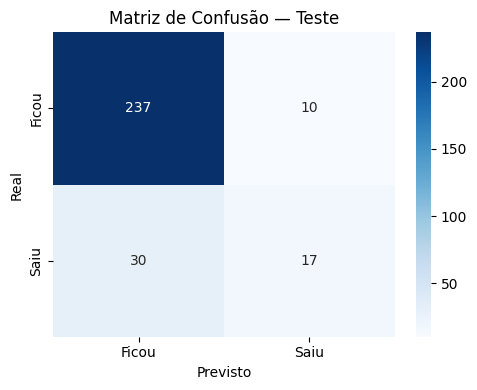


===== COMPARAÇÃO TREINO vs TESTE =====
  Métrica         Treino     Teste   Diferença
  ------------------------------------------
  Accuracy        0.9065    0.8639     +0.0425
  PRECISION       0.8175    0.6296     +0.1878
  RECALL          0.5421    0.3617     +0.1804
  F1              0.6519    0.4595     +0.1924
  AUC             0.8819    0.8170     +0.0649

  Nota: Diferença positiva indica possível overfitting.


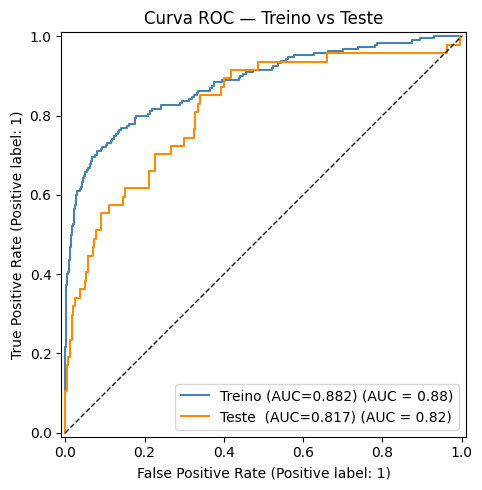


Probabilidades geradas para 1470 colaboradores.
count    1470.0000
mean        0.1591
std         0.2222
min         0.0000
25%         0.0132
50%         0.0598
75%         0.2057
90%         0.5180
max         0.9932
Name: prob_saida, dtype: float64

===== DISTRIBUICAO DAS CATEGORIAS DE RISCO =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1217         82.8%
  Medio            147         10.0%
  Alto             106          7.2%

===== PERFIL MEDIO POR CATEGORIA DE RISCO =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.071,0.065,37.969,6977.157,2.177,12.175,0.214,2.217,7.604
Medio,0.441,0.449,32.571,4438.803,1.578,7.605,0.605,1.993,4.844
Alto,0.782,0.868,30.962,3920.802,1.443,6.094,0.632,1.811,3.170



===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.993184,Alto,1,26,2340,1,1
1,0.992612,Alto,1,25,1118,1,1
2,0.984904,Alto,1,24,3172,1,1
3,0.981745,Alto,1,18,1878,1,1
4,0.980088,Alto,1,21,2174,1,1
5,0.978946,Alto,1,32,2795,1,1
6,0.960832,Alto,1,19,1675,1,1
7,0.953581,Alto,1,19,2325,1,0
8,0.951764,Alto,1,19,2121,1,1
9,0.950460,Alto,1,27,2863,1,0


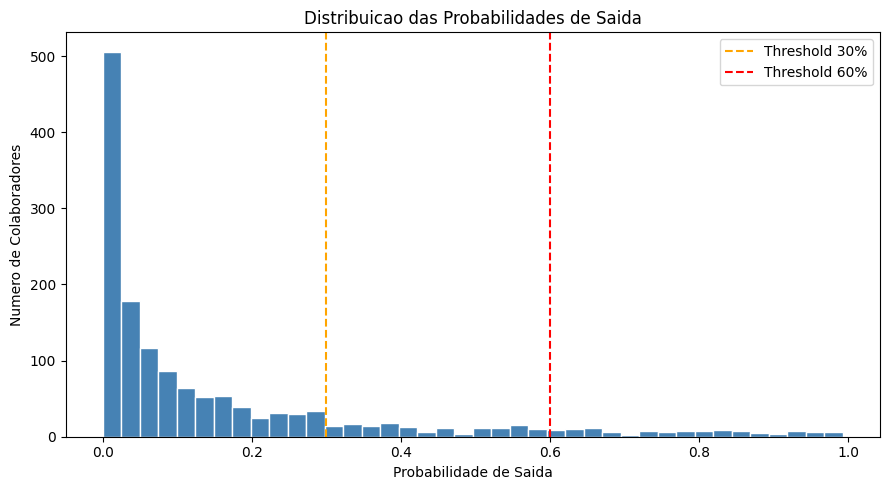

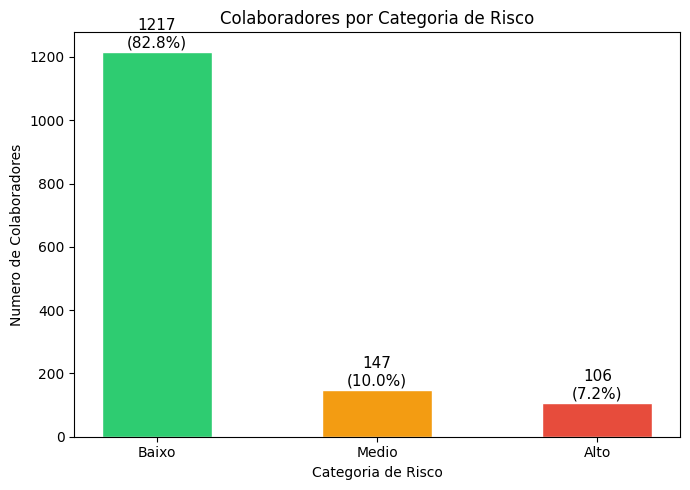

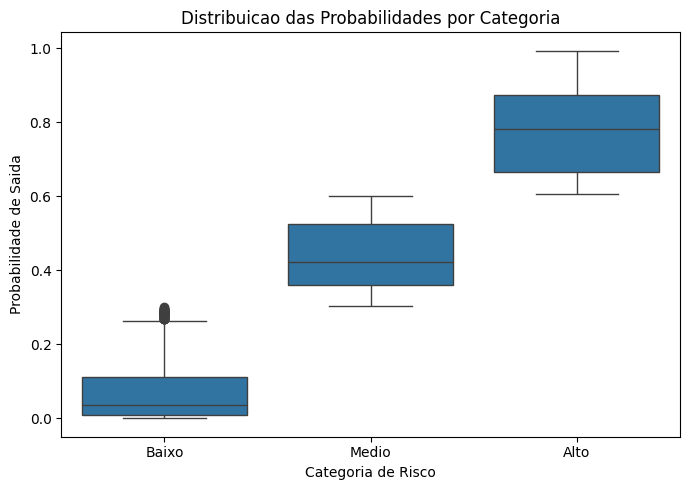


RESUMO — INDICE DE RISCO (Notebook 2)
  Modelo:         Regressao Logistica (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9065    0.8639
  Precision       0.8175    0.6296
  Recall          0.5421    0.3617
  F1-Score        0.6519    0.4595
  AUC-ROC         0.8819    0.8170

  Baixo risco:    prob < 30%  -> 1217 colaboradores
  Risco medio:    30% - 60%   -> 147 colaboradores
  Alto risco:     prob > 60%  -> 106 colaboradores


In [2]:
# ── 1. IMPORTAÇÕES ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")


# ── 2. CARREGAMENTO DO DATASET ─────────────────────────────────────────────────

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")


# ── 3. PREPARAÇÃO DAS FEATURES ────────────────────────────────────────────────

cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]

cols_remover = [c for c in cols_remover if c in df.columns]
df_model = df.drop(columns=cols_remover)

TARGET = "Attrition_bin"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
X = X.select_dtypes(include=[np.number])

print(f"Features utilizadas: {X.shape[1]}")


# ── 4. DIVISÃO TREINO / TESTE ─────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} obs | Teste: {X_test.shape[0]} obs")


# ── 5. TREINO — REGRESSÃO LOGÍSTICA ──────────────────────────────────────────

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])

pipeline.fit(X_train, y_train)
print("Modelo treinado.")


# ── 6. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE ────────────────────────────────

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"\n===== MÉTRICAS — {nome_conjunto} =====")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Precision:  {precision:.4f}")
    print(f"  Recall:     {recall:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  AUC-ROC:    {auc:.4f}")

    print(f"\n--- Classification Report ({nome_conjunto}) ---")
    print(classification_report(y, y_pred, target_names=["Ficou", "Saiu"]))

    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Ficou", "Saiu"],
                yticklabels=["Ficou", "Saiu"], ax=ax)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusão — {nome_conjunto}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{nome_conjunto.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {"conjunto": nome_conjunto, "acc": acc, "precision": precision,
            "recall": recall, "f1": f1, "auc": auc,
            "y": y, "y_proba": y_pred_proba}

resultados_treino = avaliar_modelo(pipeline, X_train, y_train, "Treino")
resultados_teste  = avaliar_modelo(pipeline, X_test,  y_test,  "Teste")


# ── 7. COMPARAÇÃO TREINO vs TESTE ─────────────────────────────────────────────

print("\n===== COMPARAÇÃO TREINO vs TESTE =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*42}")
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino[metrica]
    val_teste  = resultados_teste[metrica]
    diff       = val_treino - val_teste
    nome       = metrica.upper() if metrica != "acc" else "Accuracy"
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

print("\n  Nota: Diferença positiva indica possível overfitting.")


# ── 8. CURVAS ROC SOBREPOSTAS ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    resultados_treino["y"], resultados_treino["y_proba"],
    name=f"Treino (AUC={resultados_treino['auc']:.3f})", ax=ax, color="steelblue"
)
RocCurveDisplay.from_predictions(
    resultados_teste["y"], resultados_teste["y_proba"],
    name=f"Teste  (AUC={resultados_teste['auc']:.3f})", ax=ax, color="darkorange"
)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Treino vs Teste")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 9. GERAR PROBABILIDADES DE SAÍDA (dataset completo) ───────────────────────

df_risco = df.copy()
df_risco["prob_saida"] = pipeline.predict_proba(X)[:, 1]

print(f"\nProbabilidades geradas para {len(df_risco)} colaboradores.")
print(df_risco["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))


# ── 10. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO ──────────────────────────────────

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

df_risco["nivel_risco"] = df_risco["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem    = df_risco["nivel_risco"].value_counts()
percentagem = df_risco["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUICAO DAS CATEGORIAS DE RISCO =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


# ── 11. ANÁLISE POR CATEGORIA DE RISCO ───────────────────────────────────────

cols_analise = ["prob_saida", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco.columns:
        cols_analise.append(col)

print("\n===== PERFIL MEDIO POR CATEGORIA DE RISCO =====")
perfil = df_risco.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil)


# ── 12. TOP 20 COLABORADORES COM MAIOR RISCO ─────────────────────────────────

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco.columns:
        cols_top.append(col)

top20 = df_risco.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====")
display(top20)


# ── 13. VISUALIZAÇÕES DO ÍNDICE DE RISCO ─────────────────────────────────────

# 13.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_risco["prob_saida"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")
ax.set_xlabel("Probabilidade de Saida")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Distribuicao das Probabilidades de Saida")
ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()

# 13.2 Contagem por categoria
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(7, 5))
vals = [contagem.get(c, 0) for c in ORDEM]
bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)
for bar, cat in zip(bars, ORDEM):
    n   = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco")
plt.tight_layout()
plt.savefig("categorias_risco.png", dpi=150, bbox_inches="tight")
plt.show()

# 13.3 Boxplot por categoria
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax)
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saida")
ax.set_title("Distribuicao das Probabilidades por Categoria")
plt.tight_layout()
plt.savefig("boxplot_risco.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 14. RESUMO FINAL ──────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("RESUMO — INDICE DE RISCO (Notebook 2)")
print("=" * 55)
print(f"  Modelo:         Regressao Logistica (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino[metrica]:>8.4f}  {resultados_teste[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem.get('Alto', 0)} colaboradores")
print("=" * 55)

Bibliotecas importadas com sucesso.
Dataset carregado: 1470 linhas, 62 colunas
Features utilizadas: 53
Colunas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'OverTime_bin', 'Gender_bin', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human

,Age,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,SatisfactionIndex,WorkLifeBalance,OverTime_bin,IncomePerLevel,RatioYearsInRole,Attrition_bin
cluster,,,,,,,,,,,
0,46.021,16294.068,4.115,23.696,13.853,2.162,2.791,0.288,3977.309,0.532,0.052
1,35.160,5900.125,2.035,9.331,6.180,2.163,2.827,0.288,2842.116,0.610,0.221
2,33.804,3135.845,1.170,7.063,4.366,2.137,2.679,0.288,2742.592,0.546,0.209
3,36.789,5474.649,1.754,9.754,5.912,2.123,2.930,0.263,2906.492,0.580,0.211
4,38.744,6982.436,2.365,13.356,8.404,2.224,2.763,0.269,2918.854,0.619,0.064


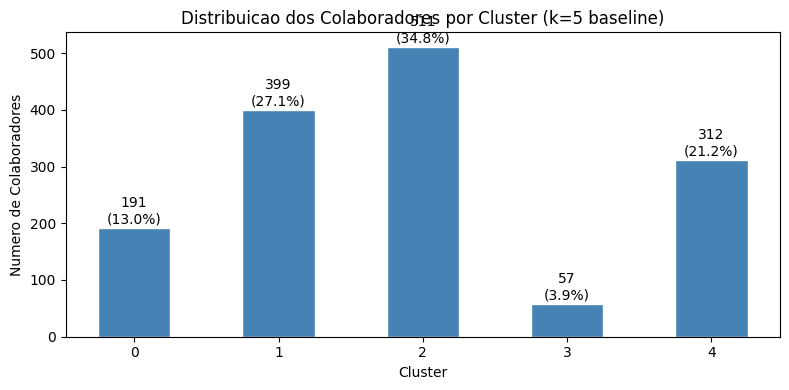

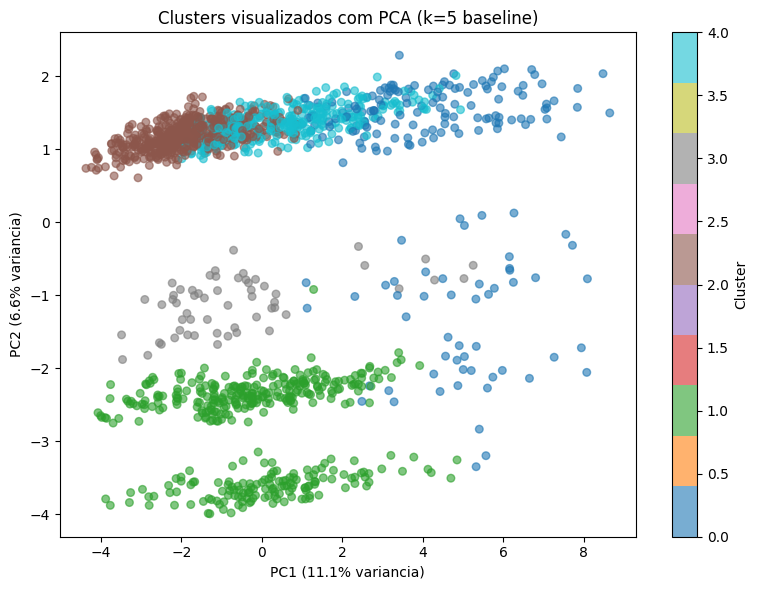

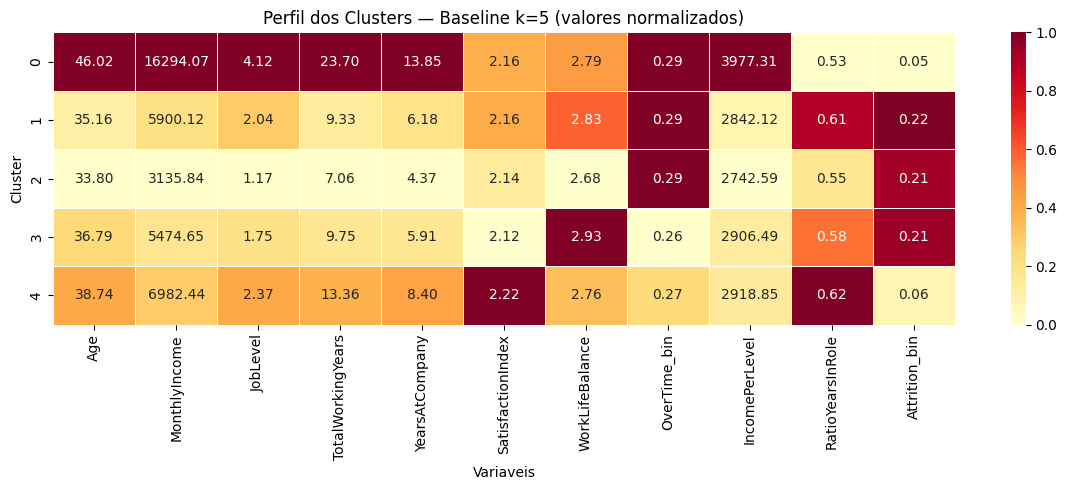

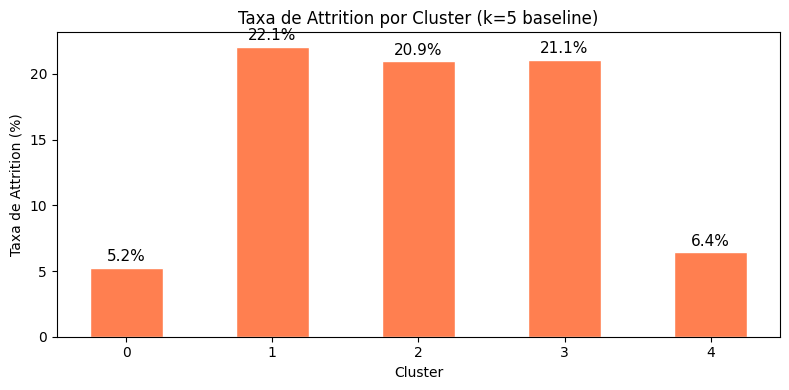


RESUMO — BASELINE CLUSTERING (Notebook 3)
  Algoritmo:        K-Means (parâmetros default)
  k baseline:       5
  Normalizacao:     StandardScaler
  Inercia:          62283.74
  Silhouette Score: 0.0826
  Meta (> 0.50):    NAO ATINGIDA

  Cluster 0: 191 colaboradores (13.0%)
  Cluster 1: 399 colaboradores (27.1%)
  Cluster 2: 511 colaboradores (34.8%)
  Cluster 3: 57 colaboradores (3.9%)
  Cluster 4: 312 colaboradores (21.2%)

  -> Referencial minimo para a otimizacao do k (fase seguinte).


In [3]:
# ── 1. IMPORTAÇÕES ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")


# ── 2. CARREGAMENTO DO DATASET ─────────────────────────────────────────────────

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")


# ── 3. PREPARAÇÃO DAS FEATURES ────────────────────────────────────────────────
# Clustering é NÃO SUPERVISIONADO
# Attrition_bin NÃO entra como feature — o modelo não pode ver quem saiu
# Remover também as colunas de texto original

cols_remover = ["Attrition", "Attrition_bin", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]

cols_remover = [c for c in cols_remover if c in df.columns]
df_cluster = df.drop(columns=cols_remover)

X = df_cluster.select_dtypes(include=[np.number])

print(f"Features utilizadas: {X.shape[1]}")
print(f"Colunas: {list(X.columns)}")


# ── 4. NORMALIZAÇÃO — OBRIGATÓRIA PARA K-MEANS ───────────────────────────────
# K-Means usa distâncias euclidianas
# Sem StandardScaler, variáveis com maior escala dominam o cálculo

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("")
print("StandardScaler aplicado.")
print(f"  Media apos escala:         {X_scaled.mean():.4f}  (deve ser ~0)")
print(f"  Desvio padrao apos escala: {X_scaled.std():.4f}  (deve ser ~1)")


# ── 5. MODELO BASELINE — K-MEANS K=5 (parâmetros default) ────────────────────
# Ponto de partida — referencial mínimo de comparação
# k=5 como valor inicial arbitrário antes de otimizar

kmeans_base = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans_base.fit_predict(X_scaled)

silhouette_base = silhouette_score(X_scaled, df["cluster"])
inercia_base    = kmeans_base.inertia_

print("")
print("===== BASELINE — K-Means k=5 (default) =====")
print(f"  Inercia:          {inercia_base:.2f}")
print(f"  Silhouette Score: {silhouette_base:.4f}")
print(f"  (Meta do projeto: Silhouette > 0.50)")
print("")
print("Distribuicao dos clusters:")
print(df["cluster"].value_counts().sort_index().to_string())


# ── 6. MÉTRICAS NO TREINO ─────────────────────────────────────────────────────
# No clustering não há treino/teste como na classificação
# A avaliação é feita com métricas internas: Inércia e Silhouette Score

print("")
print("===== MÉTRICAS DO BASELINE =====")
print(f"  Inercia (WCSS):   {inercia_base:.2f}")
print(f"    -> Mede a compacidade dos clusters (quanto menor melhor)")
print(f"  Silhouette Score: {silhouette_base:.4f}")
print(f"    -> Mede coesao interna e separacao entre clusters")
print(f"    -> Varia entre -1 e 1 (quanto maior melhor)")
print(f"    -> Meta do projeto: > 0.50")

if silhouette_base > 0.50:
    print(f"  -> META ATINGIDA com k=5 baseline")
else:
    print(f"  -> Meta nao atingida — otimizacao do k necessaria (fase seguinte)")


# ── 7. CARACTERIZAÇÃO DOS CLUSTERS ───────────────────────────────────────────

cols_perfil = []
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
            "YearsAtCompany", "SatisfactionIndex", "WorkLifeBalance",
            "OverTime_bin", "IncomePerLevel", "RatioYearsInRole",
            "Attrition_bin"]:
    if col in df.columns:
        cols_perfil.append(col)

print("")
print("===== PERFIL MEDIO POR CLUSTER =====")
perfil = df.groupby("cluster")[cols_perfil].mean().round(3)
display(perfil)


# ── 8. VISUALIZAÇÕES ──────────────────────────────────────────────────────────

# 8.1 Distribuição dos clusters
contagem = df["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contagem.index, contagem.values, color="steelblue", edgecolor="white", width=0.5)
for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f"{val}\n({val/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Cluster")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Distribuicao dos Colaboradores por Cluster (k=5 baseline)")
ax.set_xticks(contagem.index)
plt.tight_layout()
plt.savefig("distribuicao_clusters_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 8.2 Visualização com PCA (2 componentes)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
variancia = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df["cluster"], cmap="tab10",
                     alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({variancia[0]*100:.1f}% variancia)")
ax.set_ylabel(f"PC2 ({variancia[1]*100:.1f}% variancia)")
ax.set_title("Clusters visualizados com PCA (k=5 baseline)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("clusters_pca_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 8.3 Heatmap do perfil dos clusters
fig, ax = plt.subplots(figsize=(12, 5))
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
sns.heatmap(perfil_norm, annot=perfil.values, fmt=".2f",
            cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Perfil dos Clusters — Baseline k=5 (valores normalizados)")
ax.set_xlabel("Variaveis")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("heatmap_clusters_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# 8.4 Taxa de Attrition por cluster
if "Attrition_bin" in df.columns:
    attrition_cluster = df.groupby("cluster")["Attrition_bin"].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(attrition_cluster.index, attrition_cluster.values,
                  color="coral", edgecolor="white", width=0.5)
    for bar, val in zip(bars, attrition_cluster.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=11)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Taxa de Attrition (%)")
    ax.set_title("Taxa de Attrition por Cluster (k=5 baseline)")
    ax.set_xticks(attrition_cluster.index)
    plt.tight_layout()
    plt.savefig("attrition_por_cluster_baseline.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── 9. RESUMO FINAL ───────────────────────────────────────────────────────────

print("")
print("=" * 55)
print("RESUMO — BASELINE CLUSTERING (Notebook 3)")
print("=" * 55)
print(f"  Algoritmo:        K-Means (parâmetros default)")
print(f"  k baseline:       5")
print(f"  Normalizacao:     StandardScaler")
print(f"  Inercia:          {inercia_base:.2f}")
print(f"  Silhouette Score: {silhouette_base:.4f}")
print(f"  Meta (> 0.50):    {'ATINGIDA' if silhouette_base > 0.50 else 'NAO ATINGIDA'}")
print("")
for c in sorted(df["cluster"].unique()):
    n = (df["cluster"] == c).sum()
    print(f"  Cluster {c}: {n} colaboradores ({n/len(df)*100:.1f}%)")
print("")
print("  -> Referencial minimo para a otimizacao do k (fase seguinte).")
print("=" * 55)

